# Mutual information computation

In an neural network layer, the input $X$ is processed as $X \rightarrow h = f(WX) \rightarrow y = g(Wh), with $f$ and $g$ the activation functions.
The mutual information of a hidden activity variable with the inputs or outputs is measured by a MI estimator, to have a finite entropy (as $h$ is a continuous variable with a definite function)
- **Binning**: The variable $h$ is binned in a specific portion of its domain, giving $T_i = B(h_i)$. Now $T_i$ is a discrete variable with finite entropy
-

## MNIST NN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Set the seeds for reproducibility
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)

In [ ]:
# Transformations that are applied to the dataset images when they are loaded: first they are converted to tensors, then flattended from 28x28 images to 784 arrays
transform = transforms.Compose([
    transforms.ToTensor(),                # (1, 28, 28)
    transforms.Lambda(lambda x: x.view(-1))  # (784,)
])

# Load the training dataset
train_dataset = datasets.MNIST(root="MNIST", train=True, download=True, transform=transform)

# Load the test dataset
test_dataset = datasets.MNIST(
    root="MNIST", train=False, download=True, transform=transform
)

# Loaders. These shuffle the images passed in batches of 64 to the model during the training phase
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


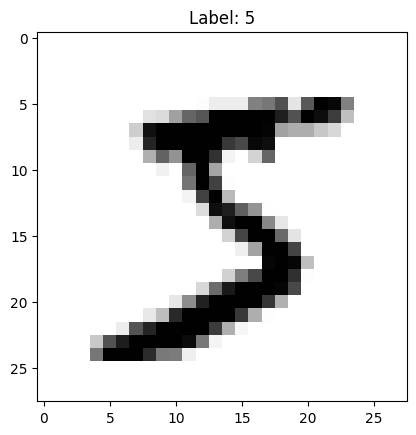

In [ ]:
# A small function made for replotting the images

def show_item(index, predicted = None):
    image, label = train_dataset.__getitem__(index)
    image = image.reshape(28,28)

    title = f'Label: {label}' if predicted==None else f'Predicted: {predicted}, true: {label}'
    plt.title(title)
    plt.imshow(image, cmap='gray_r')
    plt.show()

show_item(0)

In [ ]:
# Neural network creator

class Net(nn.Module):

    # Pass the hidden layer sizes as a tuple (NOT as a list or a int: if only one pass it as (10,))
    def __init__(self, Nh, Ni=784, No=10, act = nn.Tanh()):
    
        super().__init__()  #Initialize upper modules
        
        self.N_hidden = len(Nh)         # Number of hidden layers
        self.N_features = (Ni, *Nh)  

        # Module list (creates a list of modules that are seen from the library)
        # DO NOT USE A LIST (it is not tracked by torch when weights are updated)
        self.linears = nn.ModuleList([nn.Linear(self.N_features[i], self.N_features[i+1]) for i in range(self.N_hidden)])

        self.act = act

        self.out_layer = nn.Linear(in_features=self.N_features[-1], out_features=No)

    # This is a custom forward function that also explicitly returns the hidden variables as a tuple h
    def forward(self, x):
        # Hidden variables
        h = []
        for layer in self.linears:
            a = layer(x)
            x = self.act(a)
            h.append(x)

        return self.out_layer(x), h  


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Net(Nh = (128,64)).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
epochs = 5
loss_history = []
train_accuracy = []

outputs = []
hiddens = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_samples = 0
    correct_guess = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        pred_y, h = model(x)

        outputs.append(pred_y)
        hiddens.append(h)

        loss = loss_function(pred_y, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(pred_y, dim=1)
        correct_guess += (predictions == y).sum().item()
        total_samples += y.size(0)

    
    loss_history.append(total_loss)
    train_accuracy.append(100*correct_guess/total_samples)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")


Epoch [1/5], Loss: 312.0558
Epoch [2/5], Loss: 126.4262
Epoch [3/5], Loss: 84.3194
Epoch [4/5], Loss: 63.4523
Epoch [5/5], Loss: 48.9980


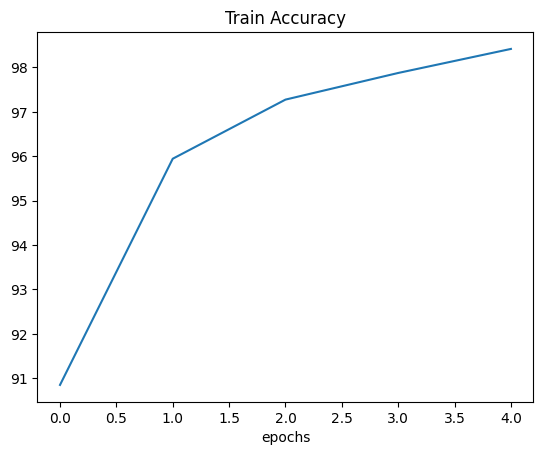

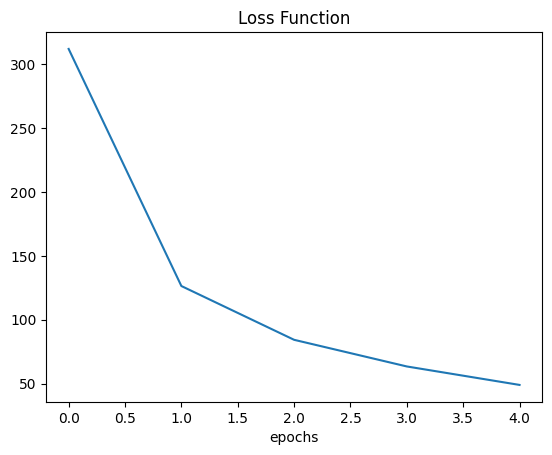

In [ ]:
plt.plot(train_accuracy)
plt.title('Train Accuracy')
plt.xlabel('epochs')
plt.show()
plt.plot(loss_history)
plt.title('Loss Function')
plt.xlabel('epochs')
plt.show()


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        outputs, h = model(x)
        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == y).sum().item()
        total += y.size(0)

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")


Test Accuracy: 97.49%


## Mutual information computation

Using binning to constrain the hidden variables to a discrete distribution and so having a finite entropy, the mutula information is $I(X:T) = H(T) - H(T|X)$ with $H(T|X)=0$ as $T_i=binning(h_i)$ and $h_i$ is a deterministic function of $X$. The values used here are multidimensionals, so using $x_i$ and $h_i$ as the components, the 